# Understand the basic Image Classification pipeline and the data-driven approach (train/predict stages) 

In [1]:
# Include all the packages need to resolve the problem
from __future__ import absolute_import, division, print_function
import numpy as np
import tensorflow as tf
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, ReLU, BatchNormalization
from keras.layers import Conv2D, MaxPooling2D

/home/siju/.local/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
/home/siju/.local/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
/home/siju/.local/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
/home/siju/.local/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:519: FutureWa

# 1. Data fetching and understand the train/val/test splits.

In [2]:
import h5py
# Open the file as readonly. The file should be present inside a directory called "data" in the same folder as code
h5f = h5py.File('./SVHN_single_grey1.h5', 'r')

# Load the training, test and validation set
x_train = h5f['X_train'][:]
y_train = h5f['y_train'][:]
x_test = h5f['X_test'][:]
y_test = h5f['y_test'][:]
x_val = h5f['X_val'][:]
y_val = h5f['y_val'][:]

# Close this file
h5f.close()

In [3]:
print("No of Train samples:", x_train.shape[0])
print("No of Test samples:", x_test.shape[0])
print("No of Val samples:", x_val.shape[0])

No of Train samples: 42000
No of Test samples: 18000
No of Val samples: 60000


In [4]:
print("Train image size:", x_train.shape[1:])

Train image size: (32, 32)


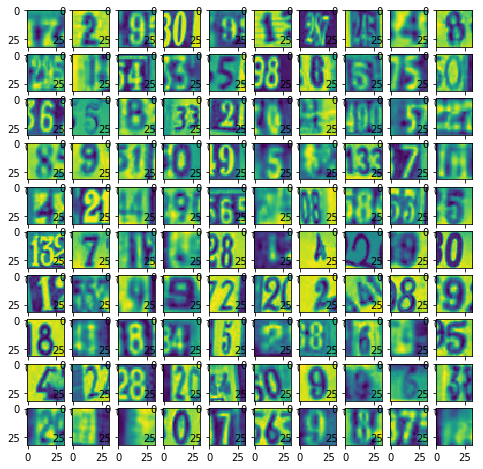

In [5]:
# View 100 sample images from the test dataset
%matplotlib inline

import matplotlib.pyplot as plt
w=10
h=10
fig=plt.figure(figsize=(8, 8))
columns = 10
rows = 10
for i in range(1, columns*rows +1):
    img = x_test[i]
    fig.add_subplot(rows, columns, i)
    plt.imshow(img)
plt.show()

# 2. Implement and apply an optimal k-Nearest Neighbor (kNN) classifier (7.5 Points)

In [6]:
from sklearn.neighbors import KNeighborsClassifier 

In [7]:
# Create a k-NN classifier with 7 neighbors: knn
knn = KNeighborsClassifier(n_neighbors=7)

In [8]:
# Fit the classifier to the training data
knn.fit(x_train.reshape(x_train.shape[0], -1), y_train)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=None, n_neighbors=7, p=2,
           weights='uniform')

In [9]:
# Print the accuracy, enable later
knn_score = knn.score(x_test.reshape(x_test.shape[0], -1), y_test)
print("KNN Score =", knn_score)

KNN Score = 0.5070555555555556


In [10]:
neighbors = np.arange(1, 9)
train_accuracy = np.empty(len(neighbors))
test_accuracy = np.empty(len(neighbors))

In [11]:
# Loop over different values of k
for i, k in enumerate(neighbors):
    # Setup a k-NN Classifier with k neighbors: knn
    knn = KNeighborsClassifier(n_neighbors=k)

    # Fit the classifier to the training data
    knn.fit(x_train.reshape(x_train.shape[0], -1), y_train)
    
    #Compute accuracy on the training set
    train_accuracy[i] = knn.score(x_train.reshape(x_train.shape[0], -1), y_train)

    #Compute accuracy on the testing set
    test_accuracy[i] = knn.score(x_test.reshape(x_test.shape[0], -1), y_test)
    
    print("Neighbors = ", k, "Train Accuracy= ", train_accuracy[i], " Test Accuracy =  ", test_accuracy[i])

Neighbors =  1 Train Accuracy= 1.0 Test Accuracy =  0.45916666666666667
Neighbors =  2 Train Accuracy= 0.7208095238095238 Test Accuracy =  0.43644444444444447
Neighbors =  3 Train Accuracy= 0.6996904761904762 Test Accuracy =  0.4617777777777778
Neighbors =  4 Train Accuracy= 0.6894761904761905 Test Accuracy =  0.48133333333333334
Neighbors =  5 Train Accuracy= 0.6815952380952381 Test Accuracy =  0.49016666666666664
Neighbors =  6 Train Accuracy= 0.6687142857142857 Test Accuracy =  0.5008888888888889
Neighbors =  7 Train Accuracy= 0.6602142857142858 Test Accuracy =  0.5070555555555556
Neighbors =  8 Train Accuracy= 0.6516666666666666 Test Accuracy =  0.5117777777777778


# 3. Print the classification metric report (2.5 Points)

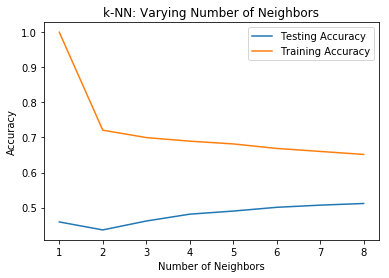

In [12]:
# Generate plot
plt.title('k-NN: Varying Number of Neighbors')
plt.plot(neighbors, test_accuracy, label = 'Testing Accuracy')
plt.plot(neighbors, train_accuracy, label = 'Training Accuracy')
plt.legend()
plt.xlabel('Number of Neighbors')
plt.ylabel('Accuracy')
plt.show()

In [36]:
knn_neighbors = np.argmax(test_accuracy)+1
knn_accuracy = max(test_accuracy)
print("Best KNN Score when neighbors=", knn_neighbors)
print("Accuracy score = ", knn_accuracy)

Best KNN Score when neighbors= 8
Accuracy score =  0.5117777777777778


# 4. Implement and apply a deep neural network classifier including (feedforward neural network, RELU activations) (5 points)

### Reshape train and test sets into shapes compatible with keras models
### (Keras expects data to be in the format (N_E.N_H,N_W,N_C) N_E = Number of Examples, N_H = height, N_W = Width, N_C = Number of Channels.)

In [14]:
# input image dimensions
img_rows, img_cols = 32, 32

#Keras expects data to be in the format (N_E.N_H,N_W,N_C)  N_E = Number of Examples, N_H = height, N_W = Width, N_C = Number of Channels.
x_train = x_train.reshape(x_train.shape[0], img_rows, img_cols, 1)
x_test = x_test.reshape(x_test.shape[0], img_rows, img_cols, 1)
x_val = x_val.reshape(x_val.shape[0], img_rows, img_cols, 1)
input_shape = (img_rows, img_cols, 1)

### Pre-processing the dataset

In [15]:
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_val = x_val.astype('float32')

#Normalizing the input
x_train /= 255
x_test /= 255
x_val /= 255
print('x_train shape:', x_train.shape)
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')
print(x_val.shape[0], 'val samples')

x_train shape: (42000, 32, 32, 1)
42000 train samples
18000 test samples
60000 val samples


### Convert Labels from digits to one hot vectors

In [16]:
np.unique(y_train), np.unique(y_test), np.unique(y_val)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8))

In [17]:
num_classes = len(np.unique(y_train))

In [18]:
import keras
# convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)
y_val = keras.utils.to_categorical(y_val, num_classes)

In [19]:
print(y_train[0])

[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]


### Building the CNN sequential model

In [20]:
batch_size = 128
num_classes = 10

In [21]:
#Initialize the model
model = Sequential()

#Add a Convolutional Layer with 32 filters of size 3X3 and activation function as 'ReLU' 
model.add(Conv2D(32, kernel_size=(3, 3),
                 activation='relu',
                 input_shape=input_shape,name='conv_1'))

#Add a Convolutional Layer with 64 filters of size 3X3 and activation function as 'ReLU' 
model.add(Conv2D(64, (3, 3), activation='relu',name='conv_2'))

#Add a MaxPooling Layer of size 2X2 
model.add(MaxPooling2D(pool_size=(2, 2),name='max_1'))

#Apply Dropout with 0.25 probability 
model.add(Dropout(0.25,name='drop_1'))

#Flatten the layer
model.add(Flatten())

#Add Fully Connected Layer with 128 units and activation function as 'ReLU'
model.add(Dense(128, activation='relu',name='dense_1'))

#Apply Dropout with 0.5 probability 
model.add(Dropout(0.5,name='drop_2'))

#Add Fully Connected Layer with 10 units and activation function as 'softmax'
model.add(Dense(num_classes, activation='softmax',name='dense_2'))






Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.


# 5. Understand and be able to implement (vectorized) backpropagation (cost stochastic gradient descent, cross entropy loss, cost functions) (2.5 points)

In [22]:
from keras.optimizers import SGD
from keras.losses import categorical_crossentropy

#To use adam optimizer for learning weights with learning rate = 0.001
optimizer = SGD(lr=0.001, decay=1e-6, momentum=0.9)
#Set the loss function and optimizer for the model training
model.compile(loss=categorical_crossentropy,
              optimizer=optimizer,
              metrics=['accuracy'])

In [23]:
#Training on the dataset
model.fit(x_train, y_train,
          batch_size=batch_size,
          epochs=20,
          #verbose=1,
          validation_data=(x_val, y_val))

Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where
Train on 42000 samples, validate on 60000 samples
Epoch 1/20
42000/42000 [==============================] - 44s 1ms/step - loss: 2.3032 - acc: 0.1046 - val_loss: 2.3005 - val_acc: 0.1274
Epoch 2/20
42000/42000 [==============================] - 42s 988us/step - loss: 2.3006 - acc: 0.1135 - val_loss: 2.2983 - val_acc: 0.1539
Epoch 3/20
42000/42000 [==============================] - 41s 977us/step - loss: 2.2981 - acc: 0.1263 - val_loss: 2.2952 - val_acc: 0.1543
Epoch 4/20
42000/42000 [==============================] - 41s 981us/step - loss: 2.2957 - acc: 0.1341 - val_loss: 2.2909 - val_acc: 0.2066
Epoch 5/20
42000/42000 [==============================] - 41s 981us/step - loss: 2.2907 - acc: 0.1527 - val_loss: 2.2838 - val_acc: 0.2076
Epoch 6/20
42000/42000 [==============================] - 42s 999us/step - loss: 2.2830 - acc: 0.1637 - val_loss: 2.2706 - val_acc: 0.2778
Epoch 7/20
42000/42000 [

In [24]:
model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv_1 (Conv2D)              (None, 30, 30, 32)        320       
_________________________________________________________________
conv_2 (Conv2D)              (None, 28, 28, 64)        18496     
_________________________________________________________________
max_1 (MaxPooling2D)         (None, 14, 14, 64)        0         
_________________________________________________________________
drop_1 (Dropout)             (None, 14, 14, 64)        0         
_________________________________________________________________
flatten_1 (Flatten)          (None, 12544)             0         
_________________________________________________________________
dense_1 (Dense)              (None, 128)               1605760   
_________________________________________________________________
drop_2 (Dropout)             (None, 128)               0         
__________

## Evaluate trained model on the test set

In [25]:
#Testing the model on test set
score = model.evaluate(x_test, y_test)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

18000/18000 [==============================] - 5s 274us/step
Test loss: 0.6844175160725912
Test accuracy: 0.8177777777777778


# 6. Implement batch normalization for training the neural network (2.5points)

In [26]:
#Initialize the model
model_1 = Sequential()

#Add a Convolutional Layer with 32 filters of size 3X3
model_1.add(Conv2D(32, kernel_size=(3, 3),
                 input_shape=input_shape,name='conv_1'))
# Apply Batchnorm
model_1.add(keras.layers.BatchNormalization(name='batchnorm_1', epsilon=0.001, momentum=0.99))
# Apply ReLU activation
model_1.add(ReLU(name='relu_1'))

#Add a Convolutional Layer with 64 filters of size 3X3 
model_1.add(Conv2D(64, (3, 3), name='conv_2'))
# Apply Batchnorm
model_1.add(keras.layers.BatchNormalization(name='batchnorm_2', epsilon=0.001, momentum=0.99))
# Apply ReLU activation
model_1.add(ReLU(name='relu_2'))

#Add a MaxPooling Layer of size 2X2 
model_1.add(MaxPooling2D(pool_size=(2, 2),name='max_1'))

# Apply Batchnorm
model_1.add(keras.layers.BatchNormalization(name='batchnorm_3', epsilon=0.001, momentum=0.99))

#Flatten the layer
model_1.add(Flatten())

#Add Fully Connected Layer with 128 units and activation function as 'ReLU'
model_1.add(Dense(128, activation='relu',name='dense_1'))

# Apply Batchnorm
model_1.add(keras.layers.BatchNormalization(name='batchnorm_4', epsilon=0.001, momentum=0.99))

#Add Fully Connected Layer with 10 units and activation function as 'softmax'
model_1.add(Dense(num_classes, activation='softmax',name='dense_2'))

In [27]:
from keras.optimizers import SGD
from keras.losses import categorical_crossentropy

#To use adam optimizer for learning weights with learning rate = 0.001
optimizer = SGD(lr=0.001, decay=1e-6, momentum=0.9)
#Set the loss function and optimizer for the model training
model_1.compile(loss=categorical_crossentropy,
              optimizer=optimizer,
              metrics=['accuracy'])

In [28]:
#Training on the dataset
model_1.fit(x_train, y_train,
          batch_size=batch_size,
          epochs=20,
          verbose=1,
          validation_data=(x_val, y_val))

Train on 42000 samples, validate on 60000 samples
Epoch 1/20
42000/42000 [==============================] - 89s 2ms/step - loss: 1.0676 - acc: 0.6693 - val_loss: 0.6790 - val_acc: 0.8002
Epoch 2/20
42000/42000 [==============================] - 87s 2ms/step - loss: 0.5262 - acc: 0.8472 - val_loss: 0.4865 - val_acc: 0.8561
Epoch 3/20
42000/42000 [==============================] - 98s 2ms/step - loss: 0.4249 - acc: 0.8765 - val_loss: 0.4964 - val_acc: 0.8524
Epoch 4/20
42000/42000 [==============================] - 88s 2ms/step - loss: 0.3660 - acc: 0.8961 - val_loss: 0.4759 - val_acc: 0.8608
Epoch 5/20
42000/42000 [==============================] - 94s 2ms/step - loss: 0.3230 - acc: 0.9083 - val_loss: 0.4235 - val_acc: 0.8787
Epoch 6/20
42000/42000 [==============================] - 97s 2ms/step - loss: 0.2876 - acc: 0.9198 - val_loss: 0.3218 - val_acc: 0.9107
Epoch 7/20
42000/42000 [==============================] - 88s 2ms/step - loss: 0.2571 - acc: 0.9307 - val_loss: 0.2950 - val_acc

In [29]:
model_1.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv_1 (Conv2D)              (None, 30, 30, 32)        320       
_________________________________________________________________
batchnorm_1 (BatchNormalizat (None, 30, 30, 32)        128       
_________________________________________________________________
relu_1 (ReLU)                (None, 30, 30, 32)        0         
_________________________________________________________________
conv_2 (Conv2D)              (None, 28, 28, 64)        18496     
_________________________________________________________________
batchnorm_2 (BatchNormalizat (None, 28, 28, 64)        256       
_________________________________________________________________
relu_2 (ReLU)                (None, 28, 28, 64)        0         
_________________________________________________________________
max_1 (MaxPooling2D)         (None, 14, 14, 64)        0         
__________

In [30]:
#Testing the model on test set
score = model_1.evaluate(x_test, y_test)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

18000/18000 [==============================] - 7s 373us/step
Test loss: 0.4425425123837259
Test accuracy: 0.8794444444444445


# 7. Understand the differences and trade-offs between traditional and NN classifiers with the help of classification metrics (5 Points)

In [38]:
print("KNN Accuracy = ", knn_accuracy)

KNN Accuracy =  0.5117777777777778


In [39]:
print('CNN accuracy:', score[1])

CNN accuracy: 0.8794444444444445


## Observations between traditional and NN classifiers
1. Accuracy is much higher for neural networks
2. Number of features and its combinations which can be extracted is limited for tradtional networks and it becomes complex as the image size increases.
3. In a Neural network there can be multiple neurons in a single layer and all of those units individually are classifiers only with some activation function like ReLu, Sigmoid etc. and there can be multiple such layers. One of the main advantage of having such a collection of classifiers is that each of those classifiers can engage themselves for finding different patterns in the data and since there are many such units, the network can learn a lot of features from the data.
4. Dataengineering can be simplified in case of NN Classifiers.
5. Adding more layers can generally improve the model performance in terms of accuracy.
6. Unlike traditional classifiers, NN Classifiers needs high-performance hardware for training and inference.
7. Traditional classifiers requires features to be accurately identified by users while NN Classifier creates new features by itself.
8. In comparison with traditional classifiers, NN classifiers needs much more time to train.
9. Unlike NN Classifiers, traditional classifiers can provide enough transparency for its decisions.
10. Model size is lesser in traditional classifiers whereas in case of NN, as the hidden layers increase, the model size increases significantly.